# Experimentation with model

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

# from transformers import AutoTokenizer, set_seed
import os, torch
import sys, argparse, time
# import inspect
import numpy as np
# from vllm import LLM, SamplingParams

sys.path.append("src") 
from llama_activate import (
    # get_llm,
    build_network,
    run_simulation,
    main, 
    call_visualizations,
    # pca_visualize
    
)

from utils.tools.path_manager import PathManager

import utils.metrics as metrics
from utils.tools.path_manager import PathManager
from classes.network import RandomNetwork, SocialDistanceAttachment
# import utils.tools.load_personas as lp
import utils.visualization as vis
# import utils.tools.reading_in as ri
import warnings

# Suppress annoying warning
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas.io.spss")

# --- Model Configuration ---
# llama_model = "meta-llama/Meta-Llama-3.1-8B-Instruct" #bigger model
# MODEL_ID = os.environ.get("LLAMA_ID", llama_model)
# CACHE_DIR = os.environ.get("TRANSFORMERS_CACHE", None)
# SEED = 1234
# set_seed(SEED)

print("Is CUDA available:", torch.cuda.is_available())

/home/choynck/thesis/ABM_based_LLMS/.venv_vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 06-02 21:41:13 [importing.py:44] Triton is installed but 0 active driver(s) found (expected 1). Disabling Triton to prevent runtime errors.
INFO 06-02 21:41:13 [importing.py:68] Triton not installed or not compatible; certain GPU-related functions will not be available.


[2026-06-02 21:41:18] INFO config.py:58: PyTorch version 2.10.0 available.


Is CUDA available: False


### Do prompt robustness analyses

Prompt sensitivity analysis
Builds a pairwise cosim heatmap that includes the un-optimised ("minimal") prompt
as the last row/column. Cell colour = cosine similarity; annotation = mean test
score of the two runs (the diagonal shows that run's own score). The minimal
row/column has no annotation since it has no test score.

Runs are sorted by test score so the top-left of each heatmap is the best run
(PHQ-9: low MAE = good, so ascending; post-gen: high quality = good, so descending).
Tick labels are the test scores themselves; the seed is shown in parentheses for
traceability without breaking the score-sorted ordering.


In [ ]:
from src.utils.sensitivity.sa_analyze import (
    load_best_prompts, load_test_scores, load_minimal_score,
    compute_prompt_robustness, _sort_by_score,
    plot_prompt_sensitivity_pair
)
import json
import numpy as np


In [2]:
model = "Qwen3.5-27B"

seeds_phq9     = [23, 24, 25, 32, 33]
seeds_post_gen = [24, 25, 28, 29, 53]

with open("data/prompts_post.json") as f:
    minimal_phq9 = json.load(f)["phq9"]["system_instruction"]

with open("data/prompts_post_minimal.json") as f:
    _raw = json.load(f)["tweet_gen"]["system_forced"]
_rules, _rest    = _raw.split("### RULES ###", 1)
_rules_body, _   = _rest.split("### CONSTRAINTS ###", 1)
minimal_post_gen = "### RULES ###" + _rules_body.rstrip()

prompts_phq9     = load_best_prompts(model, seeds_phq9,     prompt_type="phq9")
prompts_post_gen = load_best_prompts(model, seeds_post_gen, prompt_type="post_gen")
test_phq9        = load_test_scores(model, seeds_phq9,      prompt_type="phq9")
test_post_gen    = load_test_scores(model, seeds_post_gen,  prompt_type="post_gen")

minimal_score_phq9     = load_minimal_score(model, seeds_phq9,     prompt_type="phq9")
minimal_score_post_gen = load_minimal_score(model, seeds_post_gen, prompt_type="post_gen")

prompts_phq9, test_phq9, seeds_phq9, labels_phq9 = _sort_by_score(
    prompts_phq9, test_phq9, seeds_phq9, ascending=True
)
prompts_post_gen, test_post_gen, seeds_post_gen, labels_post_gen = _sort_by_score(
    prompts_post_gen, test_post_gen, seeds_post_gen, ascending=False
)

rob_phq9 = compute_prompt_robustness(
    prompts_phq9, test_scores=test_phq9,
    baseline_prompt=minimal_phq9, baseline_score=minimal_score_phq9,
    labels=labels_phq9,
)
rob_post_gen = compute_prompt_robustness(
    prompts_post_gen, test_scores=test_post_gen,
    baseline_prompt=minimal_post_gen, baseline_score=minimal_score_post_gen,
    labels=labels_post_gen,
)

for name, rob in [("PHQ-9", rob_phq9), ("Post-gen", rob_post_gen)]:
    sim = np.array(rob["sim_matrix"])
    off_mask = ~np.eye(len(sim), dtype=bool)
    print(name, "n=", len(rob["labels"]), "mean off-diag cosine:", round(sim[off_mask].mean(), 3))


/home/choynck/thesis/ABM_based_LLMS/.venv_vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PHQ-9 n= 6 mean off-diag cosine: 0.692
Post-gen n= 6 mean off-diag cosine: 0.721


In [3]:
plot_prompt_sensitivity_pair(rob_phq9, rob_post_gen, model_name=model)

Pair sensitivity plot → data/test_post/optimized_phq9/Qwen3.5-27B_sensitivity/prompt_sensitivity_pair.png


'data/test_post/optimized_phq9/Qwen3.5-27B_sensitivity/prompt_sensitivity_pair.png'

### Optimization run summaries
For each seed: best validation row, the train metric at that same step, the final test score (with std), and (for prompt optimisers) the optimised instruction. BERT block lists the hyperparameter set used at training time — verify if you re-run with different settings.

In [4]:
from src.utils.sensitivity.sa_analyze import (
    summarize_prompt_runs, print_prompt_summary,
)
import pandas as pd

MODEL_SHORT = "Qwen3.5-27B"
BASE_PHQ9   = "data/test_post/optimized_phq9"
BASE_TWEETS = "data/test_post/optimized_tweets"

phq9_seeds = [23, 24, 25, 32, 33]
phq9_df = summarize_prompt_runs(BASE_PHQ9, phq9_seeds, prompt_type="phq9",
                                 best_is="min", model_short=MODEL_SHORT)
print_prompt_summary(phq9_df, "PHQ-9 prompt optimization (MAE, lower=better)")



=== PHQ-9 prompt optimization (MAE, lower=better) ===

 seed  best_step  best_val  best_val_std  train_at_best  train_std  test_mean  test_std  test_n  batch_size  val_size  num_steps
   23          6     3.475         2.683          5.714      4.233      3.833     3.143    1200           7        40          8
   24          7     3.725         3.339          4.000      2.390      4.297     3.921    1200           7        40          8
   25          8     3.850         3.582          1.286      1.385      4.118     3.481    1200           7        40          8
   32          3     3.850         3.062          4.714      3.806      3.590     2.654    1200           7        40          8
   33          1     3.375         2.717          5.286      3.806      4.230     3.844    1200           7        40          8

--- Optimized instructions ---

[seed 23]  best_step=6  val=3.48  test=3.83
  Fill in the PHQ-9 questionnaire based on the post history. Map specific textual cues to eac

In [5]:
postgen_seeds = [24, 25, 28, 29, 52, 53]
postgen_df = summarize_prompt_runs(BASE_TWEETS, postgen_seeds, prompt_type="tweet",
                                    best_is="max", model_short=MODEL_SHORT)
print_prompt_summary(postgen_df, "Post-generation prompt optimization (quality score 0-10, higher=better)")



=== Post-generation prompt optimization (quality score 0-10, higher=better) ===

 seed  best_step  best_val  best_val_std  train_at_best  train_std  test_mean  test_std  test_n  batch_size  val_size  num_steps
   24          6     6.450         1.936          5.500      1.500       6.27     1.448     100           7        20          8
   25          5     6.950         1.532          6.167      1.213       6.39     1.490     100           7        20          8
   28          4     7.200         1.364          6.429      1.400       6.47     1.598     100           5        20          8
   29          1     7.421         1.426          4.833      0.898       6.74     1.284     100           6        20          8
   53          3     6.600         0.970          6.571      1.678       6.34     1.526     100           7        20          8

--- Optimized instructions ---

[seed 24]  best_step=6  val=6.45  test=6.27
  ### RULES ### Base your TONE and MOOD on your well-being (PHQ-9):

In [6]:
from src.utils.sensitivity.sa_analyze import summarize_bert_runs

BERT_HYPERPARAMS = {
    "architecture":   "Linear -> 64 -> 32 -> 1 (ReLU, dropout 0.2)",
    "input_dim":      "768 x 3 (MentalBERT mean || max || std)",
    "optimizer":      "Adam (no weight decay)",
    "learning_rate":  1e-4,
    "loss":           "HuberLoss(delta=1.0); MAE tracked separately",
    "lr_schedule":    "ReduceLROnPlateau(factor=0.6, patience=3)",
    "grad_clip":      "max_norm=1.0",
    "batch_size":     8,
    "max_epochs":     30,
}

bert_df = summarize_bert_runs(model_short=MODEL_SHORT)

print("=== BERT regression hyperparameters (training-time config) ===")
for k, v in BERT_HYPERPARAMS.items():
    print(f"  {k:<14} = {v}")

print("=== BERT regression — per-seed summary ===")
if bert_df.empty:
    print("(no BERT runs found)")
else:
    print(bert_df.round(3).to_string(index=False))


=== BERT regression hyperparameters (training-time config) ===
  architecture   = Linear -> 64 -> 32 -> 1 (ReLU, dropout 0.2)
  input_dim      = 768 x 3 (MentalBERT mean || max || std)
  optimizer      = Adam (no weight decay)
  learning_rate  = 0.0001
  loss           = HuberLoss(delta=1.0); MAE tracked separately
  lr_schedule    = ReduceLROnPlateau(factor=0.6, patience=3)
  grad_clip      = max_norm=1.0
  batch_size     = 8
  max_epochs     = 30
=== BERT regression — per-seed summary ===
 seed  best_epoch  best_val_mae  best_val_std  train_at_best_mae  train_at_best_std  test_mae  test_std  n_train  n_val  n_test  total_epochs  mental_bert
   34          30         3.118         2.684              2.871              2.421     2.965     2.490     9632   1161    1207            30         True
   35          28         3.011         2.529              2.872              2.430     3.042     2.464     9638   1237    1125            30         True
   36          27         2.965        

### Set variables

In [ ]:
# --- Simulation Variables ---
rounds = 600
num_agents = 200
net = "sda"
seeds = [78]
alpha = 1.0
m = 2
degree = 6
p = 0.3
k = 0
dim = 2
save = False

# Define the states you want to run (["basis", "depressed"])
states = ["basis"] 

# Create the Namespace (mimicking argparse)
args = argparse.Namespace(
    net=net,
    rounds=rounds,
    num_agents=num_agents,
    seed=seeds[0], # Initial default, will be overwritten in loop
    seeds=seeds,   # List of seeds
    m=m,
    p=p,
    k=k,
    depressed=False,
    enforce_ngrams=False,
    alpha=alpha,
    degree=degree,
    dim=dim,
    save=save,
    use_saved_network=0, # Set to integer if updating existing
    directed=True
)

network = build_network(args)

## Get Network Features

In [ ]:
all_networks_results = main(args, None, states = ["basis"])
network_results = all_networks_results["basis"][0]
network = network_results["network"]
running_fracs = network_results["running_fracs"]
fracs_dist_step = network_results["fracs_dist_step"]
path_manager = PathManager(network=network)

cd_results = metrics.all_agent_phq9_cd(network, window_size=6, shift=6)

# Get paths
data_path = path_manager.get_run_directory(is_plot=False)
plot_path = path_manager.get_run_directory(is_plot=True)
data_filename = path_manager.get_network_filename()
plot_filename = path_manager.get_plot_name()

vis.plot_agent_cd_heatmaps(network, window=6, cd_results=cd_results, metric_name="PHQ-9", path=plot_path, filename=plot_filename, shift=6)

#Maybe bit ugly here but aggregate degree weighted phq9 scores
deg_w_phq9 = metrics.degree_weighted_mean(network)
vis.plot_degree_weighted_phq9(np.array([deg_w_phq9]), plot_path, plot_filename, save=args.save)
call_visualizations(
    network, 
    plot_path, 
    plot_filename, 
    args, 
    running_fracs, 
    fracs_dist_step)

# pca_visualize(all_networks_results, plot_path, plot_filename, args, num_steps=30, shift=5)

### Create graph and visualize distributions, metrics, and network

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import powerlaw

def create_graph_from_network(network, round=0, graph=None):
    if graph is None:
        if network.directed:
            graph = nx.DiGraph()
        else:
            graph = nx.Graph()

        for agent in network.all_agents:
            graph.add_node(agent.ID, mood=0)
        for connection in network.connections:
            graph.add_edge(connection[0].ID, connection[1].ID)
    
    mood_dist = {}
    for agent in network.all_agents:
        agent_mood = agent.all_phq9_sumscores[round]
        graph.nodes[agent.ID]["mood"] = agent_mood
        mood_dist[agent_mood] = mood_dist.get(agent_mood, 0) + 1
    try:
        assortativity = nx.numeric_assortativity_coefficient(graph, "mood")
    except Exception:
        assortativity = np.nan
    return graph, assortativity, mood_dist	

print("GPU available:", torch.cuda.is_available())

GPU available: False


### Alpha sweep: calibrate network topology against real social networks

Tests `alpha = 1, 2, 3` on a lightweight SDA network (N=200, degree=6, dim=2, no LLM).
Connection probability: `p_ij = 1 / (1 + (d_ij / b)^alpha)` — `b` is auto-fitted to hit `degree`.

Well-being (age + PHQ-9) is loaded from the real dataset so assortativity reflects actual demographic clustering.

**Reference targets (Twitter / online social networks)**
| Metric | Target | Notes |
|---|---|---|
| Clustering C | 0.10–0.20 | vs ER baseline ≈ k/N = 0.03 |
| Power-law γ | 2.0–3.0 | exponent of degree distribution tail |
| KS | < 0.10 | goodness-of-fit to power law; lower = better |
| Age assortativity | 0.10–0.40 | age homophily (McPherson et al. 2001) |
| PHQ-9 assortativity | any | whether depressed agents cluster together at init |

Higher `alpha` → sharper distance cutoff → more local triangles → higher C and assortativity.

In [ ]:
import pandas as pd
import utils.tools.load_personas as lp

# combo that works:
# alpha =2.5, Sweep dim = 4, latent_weight=12.0, age_weight=2, n_clusters=5, dist_type="gaussian_clusters"

ALPHA_SWEEP  = [1, 2, 2.5, 3]
SWEEP_DEGREE = 6
SWEEP_N      = 200
SWEEP_DIM    = 4
SWEEP_SEED   = 43

# Load real well-being data so age and PHQ-9 node attributes are meaningful
_well_being = lp.load_phq9("data/confidential/phq9.sav", SWEEP_N, seed=SWEEP_SEED)

rows = []
sweep_graphs = {}

for a in ALPHA_SWEEP:
    net_sw = SocialDistanceAttachment(
        alpha=a,
        dim=SWEEP_DIM,
        degree=SWEEP_DEGREE,
        num_agents=SWEEP_N,
        seed=SWEEP_SEED,
        dist_type="gaussian_clusters",
        n_clusters=4,
        latent_weight=12.0,
        age_weight=1.5,
        well_being=_well_being,
    )

    # Build an undirected nx graph directly — avoids create_graph_from_network
    # which requires all_phq9_sumscores history that doesn't exist yet.
    g = nx.Graph()
    for agent in net_sw.all_agents:
        wb  = agent.well_being or {}
        age = wb.get("age", 0)
        phq = wb.get("phq9_sumscore", 0)
        g.add_node(agent.ID, age=age, phq9=phq)
    for conn in net_sw.connections:
        g.add_edge(conn[0].ID, conn[1].ID)
    sweep_graphs[a] = g

    degrees  = [d for _, d in g.degree()]
    mean_deg = float(np.mean(degrees))
    C        = nx.average_clustering(g)
    fit      = powerlaw.Fit(degrees, verbose=False)
    gamma    = fit.power_law.alpha
    ks       = fit.power_law.KS()

    try:
        age_assort = nx.numeric_assortativity_coefficient(g, "age")
    except Exception:
        age_assort = float("nan")

    try:
        phq_assort = nx.numeric_assortativity_coefficient(g, "phq9")
    except Exception:
        phq_assort = float("nan")

    rows.append({
        "alpha":         a,
        "mean_degree":   round(mean_deg, 2),
        "C":             round(C, 4),
        "gamma":         round(gamma, 3),
        "KS":            round(ks, 4),
        "age_assort":    round(age_assort, 4),
        "phq9_assort":   round(phq_assort, 4),
    })
    print(f"alpha={a}  mean_deg={mean_deg:.2f}  C={C:.4f}  γ={gamma:.3f}  KS={ks:.4f}"
          f"  age_r={age_assort:.4f}  phq9_r={phq_assort:.4f}")

# Erdős–Rényi reference row
er_C = SWEEP_DEGREE / (SWEEP_N - 1)
rows.append({
    "alpha": "ER ref", "mean_degree": SWEEP_DEGREE,
    "C": round(er_C, 4), "gamma": "—", "KS": "—",
    "age_assort": "—", "phq9_assort": "—",
})

sweep_df = pd.DataFrame(rows).set_index("alpha")
print()
print("=== Summary (N=200, degree=6, real well-being data) ===")
print(sweep_df.to_string())
print()
print("Reference targets  C: 0.10–0.20  |  γ: 2.0–3.0  |  KS < 0.10  |  age_r: 0.10–0.40")
print(f"ER baseline        C = k/(N-1) = {er_C:.4f}")

Adding PHQ-9 scores as an additional dimension in social space.
Adding age as an additional dimension in social space.
N = 200 target degree = 6 max possible = 199
Social Distance Attachment network initialized with average degree 6.15
Calculating best minimal value for power law fit
Power-law fit: alpha=4.316391657346299, KS=0.15165789502073457
alpha=1  mean_deg=6.15  C=0.0359  γ=4.316  KS=0.1517  age_r=0.1475  phq9_r=0.0767
Adding PHQ-9 scores as an additional dimension in social space.
Adding age as an additional dimension in social space.
N = 200 target degree = 6 max possible = 199
Social Distance Attachment network initialized with average degree 5.98
Calculating best minimal value for power law fit
Power-law fit: alpha=12.388114464875654, KS=0.1605100321187618
alpha=2  mean_deg=5.98  C=0.0551  γ=12.388  KS=0.1605  age_r=0.3835  phq9_r=0.1397
Adding PHQ-9 scores as an additional dimension in social space.
Adding age as an additional dimension in social space.
N = 200 target degre

Values less than or equal to 0 in data. Throwing out 0 or negative values
Values less than or equal to 0 in data. Throwing out 0 or negative values
Values less than or equal to 0 in data. Throwing out 0 or negative values
Values less than or equal to 0 in data. Throwing out 0 or negative values


### Network topology SA — Sobol sensitivity analysis

Varies **alpha, n_clusters, latent_weight, dim, age_weight** over the full parameter space
using Sobol quasi-random sampling (no LLM — pure graph construction).
Outputs:
- `sobol_indices.png` — S1 (first-order) and ST (total-order) per metric
- `scatter_grid.png`  — each parameter vs each metric; green = target
- `parallel_coords.png` — top-50 best-fitting samples
- `best_params.csv / top10_params.csv` — calibrated parameter sets

**Targets**

| Metric | Target | Notes |
|---|---|---|
| C | 0.10 – 0.20 | ER baseline ≈ k/N = 0.03 |
| age assortativity | 0.25 | age homophily |
| PHQ-9 assortativity | 0.03 | mental-health clustering |
| γ (power-law) | 2.0 – 3.0 | observed only |
| KS | < 0.10 | observed only |

**Runtime**: `n_sobol=256` → 3 072 builds ≈ 3–5 min with `n_jobs=-1`.

In [ ]:
from utils.sensitivity.sa_network import run_network_sa

# _well_being is loaded in the alpha sweep cell above (same N and seed)
sa_df, sa_si, sa_best = run_network_sa(
    _well_being,
    N=SWEEP_N,          # 200
    degree=SWEEP_DEGREE, # 6
    seed=SWEEP_SEED,    # 43
    n_sobol=256,        # 3 072 total builds; raise to 512 for publication
    n_jobs=-1,          # all CPUs
    dist_type="gaussian_clusters",
    out_dir="data/sensitivity/network",
)

print("\nSobol indices (S1 = first-order, ST = total-order):")
print(sa_si.pivot(index="param", columns="metric", values="S1").round(3).to_string())
print("\nBest-fitting parameters from Sobol sample:")
print(sa_best[["alpha","n_clusters","latent_weight","dim","age_weight"]].to_string())

In [18]:
#============= Semantic Entrainment & Vector Assortativity =============#

def plot_semantic_entrainment(network, mentalbert=True, path="", filename="", save=False, show_fig=True):
    """
    Calculates and plots Semantic Entrainment and Vector Assortativity over time.

    For each timestep:
    - Local Similarity: cosine similarity between each agent's tweet embedding and the
      mean embedding of their direct neighbors (all adjacent agents, regardless of
      edge direction).
    - Global Similarity: cosine similarity between each agent's tweet embedding and the
      mean embedding of the full population at that timestep (excluding self) — serves
      as a random/structural baseline for vector assortativity.

    If local similarity persistently exceeds global similarity, the network exhibits
    positive semantic assortativity (entrainment): connected agents converge in content.

    Args:
        network: Network object with .all_agents, .connections, .directed, .iterations.
        mentalbert (bool): If True, use MentalBERT embeddings; else use all-MiniLM-L6-v2.
        path (str): Directory to save the figure.
        filename (str): Filename suffix for the saved figure.
        save (bool): Whether to save the figure.
        show_fig (bool): Whether to call plt.show().

    Returns:
        fig, ax, metrics_dict — where metrics_dict contains
        'mean_local', 'std_local', 'mean_global' as np.ndarrays of length T.
    """
    from scipy.spatial.distance import cosine as cosine_dist
    import utils.metrics as _metrics
    from utils.tools.format_config import FC

    # --- Build NetworkX graph for neighbor lookups ---
    if network.directed:
        graph = nx.DiGraph()
    else:
        graph = nx.Graph()
    for agent in network.all_agents:
        graph.add_node(agent.ID)
    for connection in network.connections:
        graph.add_edge(connection[0].ID, connection[1].ID)

    id_to_idx = {agent.ID: i for i, agent in enumerate(network.all_agents)}
    T = min(len(agent.tweethistory) for agent in network.all_agents)

    # --- Batch-embed all unique valid tweets at once ---
    print("Collecting unique tweets for embedding...")
    unique_tweets = list({
        agent.tweethistory[t]
        for agent in network.all_agents
        for t in range(T)
        if agent.tweethistory[t] and agent.tweethistory[t] != FC.NO_CONTENT
    })
    if not unique_tweets:
        print("No valid tweets found in the network.")
        return None, None, {}

    model = _metrics.generate_sbert_model(mentalbert=mentalbert)
    print(f"Embedding {len(unique_tweets)} unique tweets...")
    raw_embs = model.encode(unique_tweets, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
    tweet_to_emb = dict(zip(unique_tweets, raw_embs))

    # --- Pre-build agent × timestep embedding lookup: list[list[ndarray|None]] ---
    agent_embs = []
    for agent in network.all_agents:
        row = []
        for t in range(T):
            tw = agent.tweethistory[t]
            row.append(tweet_to_emb.get(tw) if (tw and tw != FC.NO_CONTENT) else None)
        agent_embs.append(row)

    # --- Compute per-timestep similarity metrics ---
    mean_local_sims, std_local_sims, mean_global_sims = [], [], []
    print("Computing semantic entrainment per timestep...")
    for t in range(T):
        # Stack valid embeddings for this timestep
        valid_idx = [i for i in range(len(network.all_agents)) if agent_embs[i][t] is not None]
        if len(valid_idx) < 2:
            mean_local_sims.append(np.nan)
            std_local_sims.append(np.nan)
            mean_global_sims.append(np.nan)
            continue

        valid_embs = np.stack([agent_embs[i][t] for i in valid_idx])  # (N_valid, D)
        pop_sum = valid_embs.sum(axis=0)
        N = len(valid_idx)

        local_sims, global_sims = [], []
        for i, agent in enumerate(network.all_agents):
            emb = agent_embs[i][t]
            if emb is None:
                continue

            # Global (leave-one-out): O(1) using precomputed sum
            global_mean = (pop_sum - emb) / (N - 1)
            global_sims.append(1.0 - cosine_dist(emb, global_mean))

            # Local: mean embedding of neighbors whose content this agent is exposed to.
            # For directed graphs, only predecessors (incoming edges) matter for
            # lexical entrainment — those are the agents sending content to this agent.
            # For undirected graphs, all neighbors are equivalent.
            sources = graph.predecessors(agent.ID) if network.directed else graph.neighbors(agent.ID)
            neighbor_embs = [
                agent_embs[id_to_idx[nid]][t]
                for nid in sources
                if id_to_idx.get(nid) is not None and agent_embs[id_to_idx[nid]][t] is not None
            ]
            if neighbor_embs:
                local_mean = np.mean(neighbor_embs, axis=0)
                local_sims.append(1.0 - cosine_dist(emb, local_mean))

        mean_local_sims.append(np.mean(local_sims) if local_sims else np.nan)
        std_local_sims.append(np.std(local_sims) if local_sims else np.nan)
        mean_global_sims.append(np.mean(global_sims) if global_sims else np.nan)

    # --- Plot ---
    mean_local = np.array(mean_local_sims)
    std_local = np.array(std_local_sims)
    mean_global = np.array(mean_global_sims)
    timesteps = np.arange(T)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(timesteps, mean_local, color='teal', linewidth=2, label='Mean Local Cosine Similarity')
    ax.fill_between(
        timesteps, mean_local - std_local, mean_local + std_local,
        color='teal', alpha=0.2, label='±1 SD (Local)'
    )
    ax.plot(timesteps, mean_global, color='gray', linewidth=1.5, linestyle='--',
            label='Mean Global Cosine Similarity (baseline)')
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title("Semantic Entrainment & Vector Assortativity over Time")
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save and path and filename:
        plt.savefig(f"{path}/semantic_entrainment_{filename}.png", dpi=300, bbox_inches="tight")
    if show_fig:
        plt.show()
    plt.close()

    return fig, ax, {"mean_local": mean_local, "std_local": std_local, "mean_global": mean_global}

fig, ax, metrics_dict = plot_semantic_entrainment(network, mentalbert=True, path=plot_path, filename=plot_filename, save=args.save)

NameError: name 'network' is not defined

### Animation

In [ ]:
def animate_mood_distribution(network, interval=200, save_path=None, save_fig=False, show_fig=False):
    fig, ax = plt.subplots(figsize=(5, 5))
    
    
    graph, assortativity, initial_dist = create_graph_from_network(network, round=0)
    # pos = nx.spring_layout(graph, seed=42) # Seed ensures reproducibility
    
    # nodes = nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=100, 
    #                                node_color=[graph.nodes[n]['mood'] for n in graph.nodes],
    
    #                                cmap=plt.cm.RdYlGn_r, vmin=0, vmax=27)
    # edges = nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.3)

    x_bins = np.arange(0, 28) # PHQ-9 range
    counts = [initial_dist.get(i, 0)/len(network.all_agents) for i in x_bins]
    bars = ax.bar(x_bins, counts, color='teal', edgecolor='black')
    
    ax.set_ylim(0, 1)
    ax.set_xlabel("PHQ-9 Score")
    ax.set_ylabel("Mood Distribution")
    title = ax.set_title("Mood Distribution Evolution")

    def update(frame):
        # Update the graph data for the specific round
        _, assortativity, mood_dist = create_graph_from_network(network, round=frame, graph=graph)
     
        for i, bar in enumerate(bars):
            bar.set_height(mood_dist.get(x_bins[i], 0)/len(network.all_agents))
        
        all_moods = []
        for score, count in mood_dist.items():
            all_moods.extend([score] * int(count))
            
        # Calculate powerlaw alpha
        try:
            fit = powerlaw.Fit(all_moods, discrete=True, verbose=False)
            alpha = fit.alpha
        except:
            alpha = 0
            
        title.set_text(f"Round {frame} | Assortativity: {assortativity:.3f}, alpha: {alpha:.2f}")
        return bars

    total_rounds = len(network.all_agents[0].all_phq9_sumscores)
    ani = FuncAnimation(fig, update, frames=range(total_rounds), 
                        interval=interval, blit=True)
    if show_fig:
        plt.show()

    if save_fig:
        full_path = os.path.join(save_path, "mood_distribution.gif")
        print(f"Saving animation to {full_path}")
        ani.save(full_path, writer='pillow')
        
    plt.show()
    return ani

def animate_network_evolution(network, interval=10, save_path=None, save_fig=False, show_fig=False):
    fig, ax = plt.subplots(figsize=(5, 5))
    
    graph, assortativity, _ = create_graph_from_network(network, round=0)
    pos = nx.kamada_kawai_layout(graph)

    if len(network.all_agents) <= 50:
        # font_size = 10
        # show_labels = True
        node_size = 400
    else:
        # font_size = max(2, 400 // len(network.all_agents))
        node_size = max(20, 40000 // len(network.all_agents))
        # show_labels = False

    
    cmap = plt.cm.RdYlGn_r
    nodes = nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=node_size, 
                                   node_color=[graph.nodes[n]['mood'] for n in graph.nodes],
                                   cmap=cmap, vmin=0, vmax=27, node_shape='o')
    edges = nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.3, edge_color='lightgray', width=1)

    title = ax.set_title("Network Mood Evolution")
    
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])



    # Add a colorbar to indicate the scale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=27))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label='PHQ-9 Score (0-27)')
    
    plt.axis('off')

    def update(frame):
        # Update the graph data for the specific round
        nonlocal graph
        graph, assortativity, _ = create_graph_from_network(network, round=frame, graph=graph)
     
        new_colors = [graph.nodes[n]['mood'] for n in graph.nodes]
        nodes.set_array(np.array(new_colors))

        title.set_text(f"Round {frame} | Assortativity: {assortativity:.3f}")

        return nodes, title

    total_rounds = len(network.all_agents[0].all_phq9_sumscores)
    ani = FuncAnimation(fig, update, frames=range(total_rounds), 
                        interval=interval, blit=True)
    if show_fig:
        plt.show()

    if save_fig:
        full_path = os.path.join(save_path, "network_evolution.gif")
        print(f"Saving animation to {full_path}")
        ani.save(full_path, writer='pillow')
    
    if show_fig:
        plt.show()
    return ani

In [ ]:
animate_mood_distribution(network, interval=50, save_path=plot_path, save_fig=True, show_fig=True)
animate_network_evolution(network, interval=10, save_path=plot_path, save_fig=True, show_fig=True)

In [ ]:
# COSINE SIMILARITY ANALYSIS

### Phase Plot for phqq9 and Homophily

In [ ]:



def plot_phase_dw_phq9_homophily(network, ax=None, label=None, path="", filename="", save=False, show_fig=False):
    """
    Phase plot: x = degree-weighted PHQ-9, y = PHQ-9 assortativity (homophily), over time.

    Args:
        network: Network after a run (has all_phq9_sumscores, connections).
        ax: matplotlib axis; if None, create new figure.
        label: Optional legend label.
        path, filename: Used if save=True.
        save, show_fig: Whether to save or show the figure.
    """
    # X-axis: degree-weighted PHQ-9 (one value per round), same as in metrics
    dw_phq9 = metrics.degree_weighted_mean(network)
    min_rounds = len(dw_phq9)

    # if network.directed:
    #     graph = nx.DiGraph()
    # else:
    #     graph = nx.Graph()

    # for agent in network.all_agents:
    #     graph.add_node(agent.ID, mood=0)
    # for connection in network.connections:
    #     graph.add_edge(connection[0].ID, connection[1].ID)
    

    assortativities = []
    graph = None
    for t in range(min_rounds):
        graph, assortativity, _ = create_graph_from_network(network, round=t, graph=graph)
        assortativities.append(assortativity)

    assortativities = np.array(assortativities)

    if ax is None:
        fig, ax = plt.subplots()
    plot_kw = {"label": label, "alpha": 0.8}
    ax.plot(dw_phq9, assortativities, **plot_kw)
    ax.set_xlabel("Degree-weighted PHQ-9")
    ax.set_ylabel("PHQ-9 assortativity (homophily)")
    ax.set_title("Phase plot: degree-weighted PHQ-9 vs homophily")
    if label is not None:
        ax.legend()
    ax.grid(True, alpha=0.3)
    if save and path and filename:
        ax.figure.savefig(f"{path}/phase_dw_phq9_homophily_{filename}.png", dpi=300, bbox_inches="tight")
    if show_fig:
        plt.show()
    return ax



In [ ]:
# Compare phase plots across different homophily settings (dim, alpha); same degree etc.
# Lines are coloured by alpha value.
import copy


# Define (dim, alpha) combinations to compare (degree and other args stay from `args`)
dims_to_compare = [2]           # e.g. [2], [2, 3]
alphas_to_compare = [1.0]  # e.g. [0.5, 1.0, 2.0]

show_fig = True

def phase_plot_homophily_phq9(dims_to_compare, alphas_to_compare, path="", filename="", save=False, show_fig=False):
    """
    Phase plot: x = degree-weighted PHQ-9, y = PHQ-9 assortativity (homophily), over time.

    Args:
        network: Network after a run (has all_phq9_sumscores, connections).
     """

    fig, ax = plt.subplots(figsize=(8, 6))

    for dim in dims_to_compare:
        for alpha in alphas_to_compare:
            args_run = copy.copy(args)
            args_run.dim = dim
            args_run.alpha = alpha

            # retrieve network (needs to be already run)
            all_networks_results = main(args_run, None, states = ["basis"])
            network_results = all_networks_results["basis"][0]
            network = network_results["network"]

            # plot
            plot_phase_dw_phq9_homophily(
                network, ax=ax,
                label=f"α={alpha}, dim={dim}",
                show_fig=False,
            )
            
            # set axes labels
            ax.set_xlabel("Degree-weighted PHQ-9")
            ax.set_ylabel("PHQ-9 assortativity (homophily)")
            ax.set_title("Phase plot: degree-weighted PHQ-9 vs homophily")
            ax.legend(loc="best", fontsize=8)
            plt.tight_layout()
    if save:
        plt.savefig(f"{path}/phase_plot_homophily_phq9_{filename}.png", dpi=300, bbox_inches="tight")
    if show_fig:
        plt.show()
phase_plot_homophily_phq9(dims_to_compare, alphas_to_compare, path="", filename="", save=False, show_fig=False)

In [ ]:
# create network based on args
network, _, _ = run_simulation(args)
vis.print_network_phq9(network, show_fig=True)

In [ ]:
vis.print_network_phq9(network, show_fig=True)


### Generate network and run simulation

In [ ]:
print("Starting simulation via imported function...")
all_networks_results = sim_script.main(args, pipe, states)

#### Visualize CDS

In [ ]:
# Visualizing the first seed of the first state
target_state = states_to_run[0]
run_index = 0 # 0 for the first seed

if target_state in all_networks_results:
    network_data = all_networks_results[target_state][run_index]
    
    network = network_data["network"]
    running_fracs = network_data["running_fracs"]
    fracs_dist_step = network_data["fracs_dist_step"]
    
    # Initialize PathManager with the specific network instance
    path_manager = PathManager(network=network)
    
    data_path = path_manager.get_run_directory(is_plot=False)
    plot_path = path_manager.get_run_directory(is_plot=True)
    data_filename = path_manager.get_network_filename()
    plot_filename = path_manager.get_plot_name()
    
    print(f"Visualizing results for state: {target_state}")
    
    # Print tweet histories
    metrics.print_histories(network, file_dir=data_path, file_name=data_filename, save=args.save)
    
    # Standard visualizations (CDS, frequency, network,)
    call_visualizations(network, plot_path, plot_filename, args, running_fracs, fracs_dist_step)
    
    # PCA Visualization (if large enough simulation is run)
    # pca_visualize(all_networks_results, plot_path, plot_filename, args)
else:
    print(f"No results found for state {target_state}")

### Prompt optimizer metrics across seeds
Loads every `data/test_post/optimized_phq9/{MODEL}_seed*/` run, identifies the **champion seed** (lowest validation MAE), and renders two plots: (1) training & validation MAE per step with the champion bold and other seeds in light gray; (2) test MAE per PHQ-9 severity category (champion as bars with other seeds overlaid as dots), plus a bias panel limited to seeds whose `test_scores_phq9.csv` carries `avg_bias` (newer runs only). `best_val_mae` and `test_mae` are derived from the CSVs because the prompt-optimizer dirs have no `performance.json`.

Champion seed: 36  (val MAE=2.965, test MAE=2.954)
All seed runs:
  seed= 34  val MAE=3.118  test MAE=2.965
  seed= 35  val MAE=3.011  test MAE=3.042
  seed= 36  val MAE=2.965  test MAE=2.954  champion
  seed= 37  val MAE=3.011  test MAE=3.027
  seed= 38  val MAE=3.032  test MAE=2.987


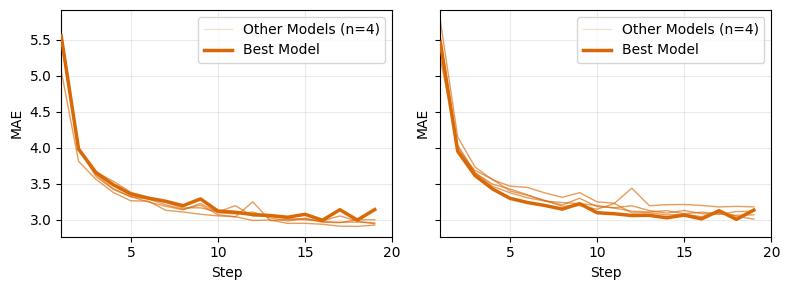

In [2]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- config ---
BERT_BASE_DIR = "data/test_post/bert_regression"
MODEL_SHORT   = "Qwen3.5-27B"
METRIC_KIND   = "auto"  # "auto" | "mae" | "score"
START_EPOCH   = 1       # inclusive
END_EPOCH     = 20    # exclusive; None = no upper cap
CHAMP_COLOR   = "#d96907"
OTHER_COLOR   = "#d96907"

# --- functions ---
def load_seed_run(d, metric_kind):
    try:
        seed = int(d.rsplit("seed", 1)[-1])
    except ValueError:
        return None
    perf_path     = os.path.join(d, "performance.json")
    traj_path     = os.path.join(d, "training_trajectory.csv")
    per_phq9_path = os.path.join(d, "test_scores_phq9.csv")
    if not (os.path.isfile(traj_path) and os.path.isfile(per_phq9_path)):
        print(f"[skip] {d} — missing training_trajectory.csv or test_scores_phq9.csv")
        return None
    traj_df     = pd.read_csv(traj_path)
    per_phq9_df = pd.read_csv(per_phq9_path)
    if os.path.isfile(perf_path):
        with open(perf_path) as fh:
            perf = json.load(fh)
        best_val    = float(perf["best_val_mae"])
        test_metric = float(perf["test_mae"])
    else:
        is_score = metric_kind == "score" or (metric_kind == "auto" and "avg_score" in per_phq9_df.columns)
        val_rows = traj_df[traj_df["split"] == "val"]
        best_val = float("nan") if val_rows.empty else float(
            val_rows["mean_score"].max() if is_score else val_rows["mean_score"].min()
        )
        per_col     = "avg_score" if is_score else "avg_mae"
        ns          = per_phq9_df["n_samples"].to_numpy(dtype=float)
        test_metric = float(np.average(per_phq9_df[per_col].to_numpy(), weights=ns)) if ns.sum() > 0 else float("nan")
    return {"seed": seed, "dir": d, "best_val_mae": best_val, "test_mae": test_metric,
            "trajectory": traj_df, "per_phq9": per_phq9_df}

# --- load data ---
seed_dirs = sorted(glob.glob(os.path.join(BERT_BASE_DIR, f"{MODEL_SHORT}_seed*")))
runs = []
for d in seed_dirs:
    r = load_seed_run(d, METRIC_KIND)
    if r is not None:
        runs.append(r)
if not runs:
    raise FileNotFoundError(f"No seed runs found under {BERT_BASE_DIR}/{MODEL_SHORT}_seed*")

IS_SCORE     = ("avg_score" in runs[0]["per_phq9"].columns) if METRIC_KIND == "auto" else (METRIC_KIND == "score")
METRIC_LABEL = "Score" if IS_SCORE else "MAE"
champion     = (max if IS_SCORE else min)(runs, key=lambda r: r["test_mae"])

print(f"Champion seed: {champion['seed']}  "
      f"(val {METRIC_LABEL}={champion['best_val_mae']:.3f}, test {METRIC_LABEL}={champion['test_mae']:.3f})")
print("All seed runs:")
for r in sorted(runs, key=lambda r: r["seed"]):
    marker = "  champion" if r["seed"] == champion["seed"] else ""
    print(f"  seed={r['seed']:>3}  val {METRIC_LABEL}={r['best_val_mae']:.3f}  "
          f"test {METRIC_LABEL}={r['test_mae']:.3f}{marker}")

# --- plot ---
fig, (ax_train, ax_val) = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for r in runs:
    df       = r["trajectory"]
    is_champ = r["seed"] == champion["seed"]
    for split, ax in [("train", ax_train), ("val", ax_val)]:
        sub = df[df["split"] == split].sort_values("step")
        sub = sub[sub["step"] >= START_EPOCH]
        if END_EPOCH is not None:
            sub = sub[sub["step"] < END_EPOCH]
        if sub.empty:
            continue
        ax.plot(
            sub["step"], sub["mean_score"],
            color=CHAMP_COLOR if is_champ else OTHER_COLOR,
            linewidth=2.5 if is_champ else 1.0,
            alpha=1.0 if is_champ else 0.65,
            zorder=3 if is_champ else 2,
        )

n_other        = len(runs) - 1
legend_handles = [
    Line2D([0], [0], color=OTHER_COLOR, linewidth=1.0, alpha=0.2, label=f"Other Models (n={n_other})"),
    Line2D([0], [0], color=CHAMP_COLOR, linewidth=2.5, label="Best Model"),
]
for ax, split in [(ax_train, "train"), (ax_val, "val")]:
    sub   = df[df["split"] == split]
    start = max(START_EPOCH, sub["step"].min()) if not sub.empty else START_EPOCH
    end   = sub["step"].max() if END_EPOCH is None else min(END_EPOCH, sub["step"].max())
    ax.set_xlabel("Step")
    ax.set_ylabel(METRIC_LABEL)
    ax.set_xlim(start, end)
    ax.grid(True, alpha=0.25)
    ax.set_axisbelow(True)
    ax.legend(handles=legend_handles, loc="best")

fig.tight_layout()
plt.savefig(f"{BERT_BASE_DIR}/{MODEL_SHORT}_train_val_{METRIC_LABEL.lower()}_across_seeds.png",
            dpi=300, bbox_inches="tight")
plt.show()


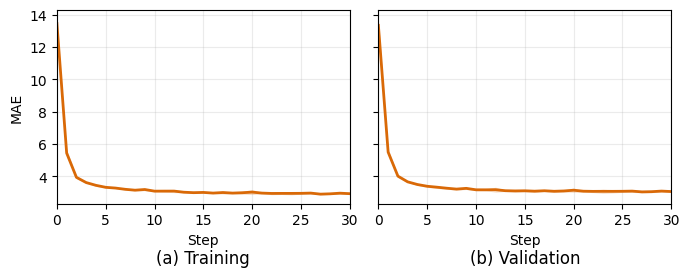

In [3]:
# --- config ---
START_EPOCH_AGG = 0     # inclusive
END_EPOCH_AGG   = None  # exclusive; None = no upper cap
LINE_COLOR      = "#d96907"
BAND_ALPHA      = 0.22

# --- data preparation ---
long_traj = pd.concat(
    [r["trajectory"].assign(_seed=r["seed"]) for r in runs],
    ignore_index=True,
)
long_traj = long_traj[long_traj["step"] >= START_EPOCH_AGG]
if END_EPOCH_AGG is not None:
    long_traj = long_traj[long_traj["step"] < END_EPOCH_AGG]

# --- plot ---
fig, (ax_train, ax_val) = plt.subplots(1, 2, figsize=(7, 3), sharey=True)
for split, ax, panel_title in [
    ("train", ax_train, "(a) Training"),
    ("val",   ax_val,   "(b) Validation"),
]:
    sub = long_traj[long_traj["split"] == split]
    if sub.empty:
        ax.set_xlabel("Step")
        ax.set_ylabel(METRIC_LABEL)
        continue
    agg = (
        sub.groupby("step")["mean_score"]
           .agg(["mean", "std", "count"])
           .reset_index()
           .sort_values("step")
    )
    band = agg["std"].fillna(0.0)
    ax.plot(agg["step"], agg["mean"], color=LINE_COLOR, linewidth=2.0,
            label=f"Mean across {len(runs)} seeds")
    ax.fill_between(
        agg["step"], agg["mean"] - band, agg["mean"] + band,
        color=LINE_COLOR, alpha=BAND_ALPHA, linewidth=0, label="±1 SD across seeds",
    )
    start = max(START_EPOCH_AGG, sub["step"].min())
    end   = sub["step"].max() if END_EPOCH_AGG is None else min(END_EPOCH_AGG, sub["step"].max())
    ax.set_xlabel("Step")
    if split == "train":
        ax.set_ylabel(METRIC_LABEL)
    ax.set_title(panel_title, y=-0.35)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(start, end)
    ax.set_axisbelow(True)

fig.tight_layout()
plt.savefig(f"{BERT_BASE_DIR}/{MODEL_SHORT}_mean_sd_{METRIC_LABEL.lower()}_across_seeds.png",
            dpi=300, bbox_inches="tight")
plt.show()


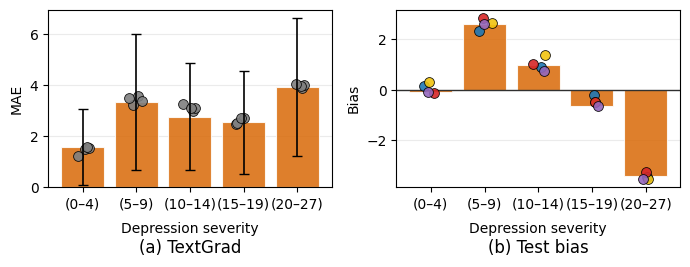

In [4]:
# === Plot 2: test metric + bias/iter10 by PHQ-9 severity category ===

# --- config ---
CATEGORIES = [
    ("(0–4)",   range(0,  5)),
    ("(5–9)",   range(5, 10)),
    ("(10–14)", range(10, 15)),
    ("(15–19)", range(15, 20)),
    ("(20–27)", range(20, 28)),
]
BAR_COLOR   = "#d96907"
DOT_SIZE    = 50
METRIC_COL  = "avg_score" if IS_SCORE else "avg_mae"
ITER10_PATH     = "data/prompt_optimization_h/qwen27_baseline/iter_10/test_scores_phq9.csv"
ITER10_RAW_PATH = "data/prompt_optimization_h/qwen27_baseline/iter_10/test_raw_scores.csv"
SEED_PALETTE = [
    "#1f77b4", "#f1c40f", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]

# --- derived variables ---
sorted_seeds = sorted(r["seed"] for r in runs)
seed_color   = {s: SEED_PALETTE[i % len(SEED_PALETTE)] for i, s in enumerate(sorted_seeds)}

# --- functions ---
def aggregate_per_phq9(df):
    """Weighted mean (and optional bias) per severity category."""
    has_bias = "avg_bias" in df.columns
    out = {}
    for label, phq_range in CATEGORIES:
        sub = df[df["phq9"].isin(list(phq_range))]
        if sub.empty:
            continue
        ns = sub["n_samples"].to_numpy(dtype=float)
        entry = {"metric": float(np.average(sub[METRIC_COL].to_numpy(), weights=ns)), "n": int(ns.sum())}
        if has_bias:
            entry["bias"] = float(np.average(sub["avg_bias"].to_numpy(), weights=ns))
        out[label] = entry
    return out

def compute_sd_per_category(raw_df, labels):
    """Per-sample SD of scores (or abs errors) within each severity category."""
    if not IS_SCORE:
        raw_df = raw_df.copy()
        raw_df["abs_err"] = (raw_df["true_phq9"] - raw_df["pred_phq9"]).abs()
    sds = []
    for lbl in labels:
        _, phq_range = next((c, r) for c, r in CATEGORIES if c == lbl)
        if IS_SCORE:
            vals = raw_df[raw_df["phq9"].isin(list(phq_range))]["score"]
        else:
            vals = raw_df[raw_df["true_phq9"].isin(list(phq_range))]["abs_err"]
        sds.append(float(vals.std(ddof=1)) if len(vals) > 1 else 0.0)
    return sds

# --- data preparation ---
bias_runs     = [r for r in runs if "avg_bias" in r["per_phq9"].columns]
show_bias     = len(bias_runs) > 0
bias_champion = (max if IS_SCORE else min)(bias_runs, key=lambda r: r["test_mae"]) if show_bias else None

champ_agg  = aggregate_per_phq9(champion["per_phq9"])
labels     = [lbl for lbl, _ in CATEGORIES if lbl in champ_agg]
champ_vals = [champ_agg[l]["metric"] for l in labels]
x          = np.arange(len(labels))

raw_path      = os.path.join(champion["dir"], "test_raw_scores.csv")
champ_sd_vals = compute_sd_per_category(pd.read_csv(raw_path), labels) if os.path.isfile(raw_path) else None

show_iter10 = IS_SCORE and not show_bias and os.path.isfile(ITER10_PATH)
if show_iter10:
    iter10_agg    = aggregate_per_phq9(pd.read_csv(ITER10_PATH))
    iter10_labels = [lbl for lbl, _ in CATEGORIES if lbl in iter10_agg]
    iter10_x      = np.arange(len(iter10_labels))
    iter10_vals    = [iter10_agg[l]["metric"] for l in iter10_labels]
    iter10_sd_vals = compute_sd_per_category(pd.read_csv(ITER10_RAW_PATH), iter10_labels) if os.path.isfile(ITER10_RAW_PATH) else None

if show_bias:
    bias_champ_agg = aggregate_per_phq9(bias_champion["per_phq9"])
    bias_labels    = [lbl for lbl, _ in CATEGORIES if lbl in bias_champ_agg]
    bias_x         = np.arange(len(bias_labels))
    champ_biases   = [bias_champ_agg[l]["bias"] for l in bias_labels]

# --- plot ---
if show_bias:
    fig, (ax_mae, ax_bias) = plt.subplots(1, 2, figsize=(7, 3.0), sharex=False)
elif show_iter10:
    fig, (ax_mae, ax_iter10) = plt.subplots(1, 2, figsize=(7, 3.0), sharex=False, sharey=True)
    ax_bias = None
else:
    fig, ax_mae = plt.subplots(figsize=(5.2, 3.5))
    ax_bias = None

ax_mae.bar(x, champ_vals, color=BAR_COLOR, edgecolor="white", linewidth=0.8, alpha=0.85)
if champ_sd_vals is not None:
    ax_mae.errorbar(x, champ_vals, yerr=champ_sd_vals, fmt="none",
                    ecolor="black", capsize=3.5, elinewidth=1.2, zorder=5)

if show_bias:
    ax_bias.bar(bias_x, champ_biases, color=BAR_COLOR, edgecolor="white", linewidth=0.8, alpha=0.85)
    ax_bias.axhline(0, color="black", linewidth=1.0, alpha=0.8)
elif show_iter10:
    ax_iter10.bar(iter10_x, iter10_vals, color=BAR_COLOR, edgecolor="white", linewidth=0.8, alpha=0.85)
    if iter10_sd_vals is not None:
        ax_iter10.errorbar(iter10_x, iter10_vals, yerr=iter10_sd_vals, fmt="none",
                           ecolor="black", capsize=3.5, elinewidth=1.2, zorder=5)

jitter_rng = np.random.default_rng(0)
for r in runs:
    if r["seed"] == champion["seed"]:
        continue
    agg = aggregate_per_phq9(r["per_phq9"])
    for i, lbl in enumerate(labels):
        if lbl not in agg:
            continue
        xi = x[i] + jitter_rng.uniform(-0.14, 0.14)
        ax_mae.scatter(xi, agg[lbl]["metric"], color="grey", s=DOT_SIZE,
                       alpha=0.9, edgecolor="black", linewidth=0.6, zorder=4)

if show_bias:
    for r in bias_runs:
        if r["seed"] == bias_champion["seed"]:
            continue
        agg = aggregate_per_phq9(r["per_phq9"])
        for i, lbl in enumerate(bias_labels):
            if lbl not in agg or "bias" not in agg[lbl]:
                continue
            xi = bias_x[i] + jitter_rng.uniform(-0.14, 0.14)
            ax_bias.scatter(xi, agg[lbl]["bias"], color=seed_color[r["seed"]], s=DOT_SIZE,
                            alpha=0.9, edgecolor="black", linewidth=0.6, zorder=4)

extra_panels = ([(ax_bias, bias_labels, bias_x)] if show_bias else []) + \
               ([(ax_iter10, iter10_labels, iter10_x)] if show_iter10 else [])
for ax, these_labels, these_x in [(ax_mae, labels, x)] + extra_panels:
    ax.set_xticks(these_x)
    ax.set_xticklabels(these_labels, fontsize=10)
    ax.set_xlabel("Depression severity", labelpad=8)
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_axisbelow(True)

ax_mae.set_ylabel(METRIC_LABEL)
ax_mae.set_title("(a) TextGrad" if (show_bias or show_iter10) else f"Test {METRIC_LABEL}", y=-0.42)
if show_bias:
    ax_bias.set_ylabel("Bias")
    ax_bias.set_title("(b) Test bias", y=-0.42)
elif show_iter10:
    # ax_iter10.set_ylabel(METRIC_LABEL)
    ax_iter10.set_title("(b) Human", y=-0.42)

fig.tight_layout()
plt.savefig(f"{BERT_BASE_DIR}/{MODEL_SHORT}_test_mean_sd_{METRIC_LABEL.lower()}_per_phq9.png",
            dpi=300, bbox_inches="tight")
plt.show()
